# Lab 9 : Analyse de Texte (Text Analysis) avec TextBlob et NLTK

Dans ce lab, nous explorons les techniques fondamentales de **traitement automatique du langage naturel (NLP)** appliquees a l'analyse d'avis produits.

## Objectifs du Lab
1. **Tokenisation** : Decouper le texte en mots et phrases
2. **Lemmatisation** : Reduire les mots a leur forme canonique
3. **POS Tagging** : Etiquetage grammatical (noms, verbes, adjectifs...)
4. **Extraction de syntagmes nominaux** : Identifier les groupes nominaux
5. **Analyse de sentiment** : Calculer la polarite et subjectivite
6. **Visualisation** : Representer les resultats avec Matplotlib/Seaborn

## Dataset
15 **avis produits** (en anglais) avec sentiment associe :
- **Positifs** : 7 avis
- **Negatifs** : 6 avis
- **Neutres** : 2 avis

## Pipeline NLP
```
Texte brut
   -> Tokenisation (mots, phrases)
   -> Pre-traitement (lowercase, stop words)
   -> Lemmatisation (formes canoniques)
   -> POS Tagging (categories grammaticales)
   -> Analyse de sentiment (polarite, subjectivite)
   -> Visualisation
```

## Librairies
| Librairie | Role |
|-----------|------|
| `TextBlob` | Tokenisation, lemmatisation, POS, sentiment |
| `NLTK` | Ressources linguistiques (WordNet, stopwords) |
| `Matplotlib` | Visualisations |
| `Seaborn` | Graphiques statistiques |
| `WordCloud` | Nuages de mots apres lemmatisation |

In [1]:
# ============================================================
# SETUP : IMPORTS ET TELECHARGEMENT DES RESSOURCES NLTK
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter

from textblob import TextBlob, Word
from textblob.wordnet import VERB, NOUN, ADJ, ADV
from wordcloud import WordCloud, STOPWORDS
import nltk

# Telechargement des ressources NLTK necessaires
nltk.download('punkt',                    quiet=True)
nltk.download('punkt_tab',                quiet=True)
nltk.download('stopwords',                quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet',                  quiet=True)

from nltk.corpus import stopwords as nltk_stopwords

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('=' * 60)
print('SETUP COMPLETE')
print('=' * 60)
print('  TextBlob : OK')
print('  NLTK     : OK (ressources telechargees)')
print('  WordCloud: OK')
print('  Matplotlib/Seaborn : OK')
print('=' * 60)

SETUP COMPLETE
  TextBlob : OK
  NLTK     : OK (ressources telechargees)
  WordCloud: OK
  Matplotlib/Seaborn : OK


## Dataset : Avis Produits

Le meme dataset que le Lab 8 est utilise pour la coherence :
**15 avis produits** avec 3 classes de sentiment (positif, negatif, neutre).

In [2]:
# ============================================================
# DATASET : 15 AVIS PRODUITS
# ============================================================

reviews_with_sentiment = [
    ('This product is absolutely amazing! I love it so much.', 'positive'),
    ('The features are fantastic and it works perfectly.', 'positive'),
    ('I am extremely happy with this purchase. Highly recommended!', 'positive'),
    ('What a terrible experience. The product broke after just one use.', 'negative'),
    ('This is the worst item I have ever bought. Complete waste of money.', 'negative'),
    ('I was so disappointed. It did not meet my expectations at all.', 'negative'),
    ("It's okay, but nothing special. Could be better.", 'neutral'),
    ("Good value for the price. I'm satisfied.", 'positive'),
    ('The customer service was awful and unhelpful.', 'negative'),
    ('Really impressed with the quality and performance!', 'positive'),
    ("Meh, it's alright. Not great, not bad.", 'neutral'),
    ('Avoid this product at all costs! Seriously flawed.', 'negative'),
    ('So glad I bought this! It has made my life easier.', 'positive'),
    ('The setup was confusing and the instructions were unclear.', 'negative'),
    ('A solid product that does exactly what it says.', 'positive'),
]

positive_reviews = [r for r, s in reviews_with_sentiment if s == 'positive']
negative_reviews = [r for r, s in reviews_with_sentiment if s == 'negative']
neutral_reviews  = [r for r, s in reviews_with_sentiment if s == 'neutral']
all_reviews      = [r for r, _ in reviews_with_sentiment]

print('=' * 70)
print('DATASET - APERCU')
print('=' * 70)
print(f'  Total  : {len(reviews_with_sentiment)} avis')
print(f'  Positif: {len(positive_reviews)} | Negatif: {len(negative_reviews)} | Neutre: {len(neutral_reviews)}')
print()
print('Premiers avis :')
for review, sentiment in reviews_with_sentiment[:5]:
    print(f'  [{sentiment.upper():8}] {review}')

DATASET - APERCU
  Total  : 15 avis
  Positif: 7 | Negatif: 6 | Neutre: 2

Premiers avis :
  [POSITIVE] This product is absolutely amazing! I love it so much.
  [POSITIVE] The features are fantastic and it works perfectly.
  [POSITIVE] I am extremely happy with this purchase. Highly recommended!
  [NEGATIVE] What a terrible experience. The product broke after just one use.
  [NEGATIVE] This is the worst item I have ever bought. Complete waste of money.


## Step 1 : Tokenisation

### Qu'est-ce que la Tokenisation ?
La **tokenisation** est la premiere etape du preprocessing NLP. Elle consiste a decouper le texte en unites elementaires appelees **tokens** :
- **Tokenisation en mots** : 'I love this product' -> ['I', 'love', 'this', 'product']
- **Tokenisation en phrases** : Decoupe le texte en phrases completes

**Utilite :**
- Preparer le texte pour les etapes suivantes (lemmatisation, POS tagging)
- Compter les mots, calculer des statistiques
- Identifier la structure du texte

In [3]:
# ============================================================
# STEP 1 : TOKENISATION
# ============================================================
print('STEP 1 : TOKENISATION')
print('=' * 70)

print('--- Tokenisation en mots ---')
for review, sentiment in reviews_with_sentiment[:4]:
    blob = TextBlob(review)
    print(f'  [{sentiment.upper():8}] "{review[:50]}..."')
    print(f'    Tokens ({len(blob.words)}) : {list(blob.words[:8])}...')
    print()

print('--- Tokenisation en phrases (exemple) ---')
multi_sentence = (
    'The product arrived quickly. It was well packaged. '
    'However, the quality was disappointing. I would not buy it again.'
)
blob_multi = TextBlob(multi_sentence)
print(f'  Texte : "{multi_sentence[:80]}..."')
print(f'  Phrases ({len(blob_multi.sentences)}) :')
for i, sentence in enumerate(blob_multi.sentences):
    print(f'    Phrase {i+1}: {sentence}')

print()
print('Statistiques globales du corpus :')
total_words = sum(len(TextBlob(r).words) for r in all_reviews)
avg_words   = total_words / len(all_reviews)
print(f'  Total de mots (brut)   : {total_words}')
print(f'  Moyenne mots par avis  : {avg_words:.1f}')
print(f'  Avis le plus court     : {min(len(TextBlob(r).words) for r in all_reviews)} mots')
print(f'  Avis le plus long      : {max(len(TextBlob(r).words) for r in all_reviews)} mots')

STEP 1 : TOKENISATION
--- Tokenisation en mots ---
  [POSITIVE] "This product is absolutely amazing! I love it so m..."
    Tokens (10) : ['This', 'product', 'is', 'absolutely', 'amazing', 'I', 'love', 'it']...

  [POSITIVE] "The features are fantastic and it works perfectly...."
    Tokens (8) : ['The', 'features', 'are', 'fantastic', 'and', 'it', 'works', 'perfectly']...

  [POSITIVE] "I am extremely happy with this purchase. Highly re..."
    Tokens (9) : ['I', 'am', 'extremely', 'happy', 'with', 'this', 'purchase', 'Highly']...

  [NEGATIVE] "What a terrible experience. The product broke afte..."
    Tokens (11) : ['What', 'a', 'terrible', 'experience', 'The', 'product', 'broke', 'after']...

--- Tokenisation en phrases (exemple) ---
  Texte : "The product arrived quickly. It was well packaged. However, the quality was disa..."
  Phrases (4) :
    Phrase 1: The product arrived quickly.
    Phrase 2: It was well packaged.
    Phrase 3: However, the quality was disappointing.
    Phr

## Step 2 : POS Tagging (Etiquetage Grammatical)

### Qu'est-ce que le POS Tagging ?
Le **Part-of-Speech Tagging** (etiquetage grammatical) associe a chaque mot sa **categorie grammaticale** :

| Tag | Categorie | Exemple |
|-----|-----------|--------|
| `NN` | Nom commun singulier | *product, quality* |
| `NNP` | Nom propre | *Amazon, Google* |
| `JJ` | Adjectif | *amazing, terrible* |
| `VBZ` | Verbe (3e pers. sg.) | *works, is* |
| `RB` | Adverbe | *absolutely, really* |
| `CC` | Conjonction | *and, but* |

**Pourquoi c'est utile ?**
- Extraire uniquement les **adjectifs** pour analyser le sentiment
- Identifier les **noms** (sujets des avis : product, service, quality)
- Preparer la lemmatisation contextualisee (un verbe et un nom se lemmatisent differemment)

STEP 2 : POS TAGGING (ETIQUETAGE GRAMMATICAL)
--- Exemple de POS Tagging ---
  Phrase : "This amazing product works perfectly and makes my life easier."
  Tags   : [('This', 'DT'), ('amazing', 'JJ'), ('product', 'NN'), ('works', 'VBZ'), ('perfectly', 'RB'), ('and', 'CC'), ('makes', 'VBZ'), ('my', 'PRP$'), ('life', 'NN'), ('easier', 'JJR')]

--- Categories grammaticales extraites ---
  Top adjectifs : ['amazing', 'fantastic', 'happy', 'recommended', 'terrible', 'worst', 'complete', 'disappointed']
  Top noms      : ['product', 'features', 'purchase', 'experience', 'use', 'item', 'waste', 'money']
  Top adverbes  : ['not', 'absolutely', 'much', 'perfectly', 'extremely', 'highly', 'just', 'ever']


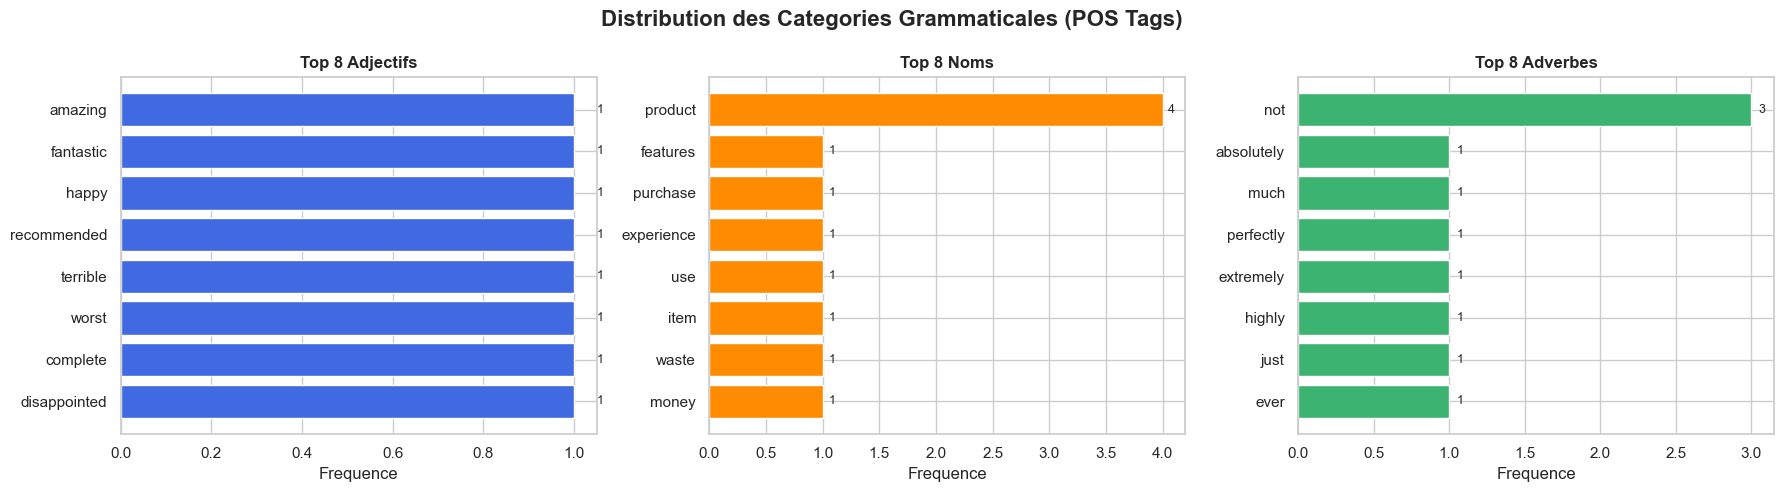


Total adjectifs trouves : 23
Total noms trouves      : 25
Total adverbes trouves  : 13
-> Les adjectifs les plus frequents reflectent bien le sentiment des avis.


In [4]:
# ============================================================
# STEP 2 : POS TAGGING
# ============================================================
print('STEP 2 : POS TAGGING (ETIQUETAGE GRAMMATICAL)')
print('=' * 70)

print('--- Exemple de POS Tagging ---')
example_sentence = 'This amazing product works perfectly and makes my life easier.'
blob_pos = TextBlob(example_sentence)
print(f'  Phrase : "{example_sentence}"')
print(f'  Tags   : {blob_pos.tags}')
print()

# Extraction des adjectifs et noms sur tout le corpus
all_adjectives = []
all_nouns      = []
all_adverbs    = []

for review, _ in reviews_with_sentiment:
    blob = TextBlob(review.lower())
    for word, tag in blob.tags:
        word_clean = re.sub(r'[^a-z]', '', word)
        if not word_clean or len(word_clean) < 3:
            continue
        if tag.startswith('JJ'):   # Adjectifs
            all_adjectives.append(word_clean)
        elif tag.startswith('NN'): # Noms
            all_nouns.append(word_clean)
        elif tag.startswith('RB'): # Adverbes
            all_adverbs.append(word_clean)

print('--- Categories grammaticales extraites ---')
top_adj   = Counter(all_adjectives).most_common(8)
top_nouns = Counter(all_nouns).most_common(8)
top_adv   = Counter(all_adverbs).most_common(8)

print(f'  Top adjectifs : {[w for w, _ in top_adj]}')
print(f'  Top noms      : {[w for w, _ in top_nouns]}')
print(f'  Top adverbes  : {[w for w, _ in top_adv]}')

# Visualisation de la distribution des POS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des Categories Grammaticales (POS Tags)', fontsize=16, fontweight='bold')

for ax, (title, top, color) in zip(axes, [
    ('Top 8 Adjectifs', top_adj, 'royalblue'),
    ('Top 8 Noms',      top_nouns, 'darkorange'),
    ('Top 8 Adverbes',  top_adv, 'mediumseagreen'),
]):
    if top:
        words, cnts = zip(*top)
        ax.barh(list(words)[::-1], list(cnts)[::-1], color=color, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Frequence')
        for i, v in enumerate(list(cnts)[::-1]):
            ax.text(v + 0.05, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print()
print(f'Total adjectifs trouves : {len(all_adjectives)}')
print(f'Total noms trouves      : {len(all_nouns)}')
print(f'Total adverbes trouves  : {len(all_adverbs)}')
print('-> Les adjectifs les plus frequents reflectent bien le sentiment des avis.')

## Step 3 : Extraction de Syntagmes Nominaux (Noun Phrases)

### Qu'est-ce qu'un Syntagme Nominal ?
Un **syntagme nominal (noun phrase)** est un groupe de mots dont le noyau est un nom.
Exemples : *'great product'*, *'customer service'*, *'solid quality'*

**Utilite pour l'analyse d'avis :**
- Extraire les **aspects evalues** dans les avis (aspect-based sentiment analysis)
- Identifier les **attributs produits** les plus mentionnes
- Donne plus de contexte que les mots isoles

In [5]:
# ============================================================
# STEP 3 : EXTRACTION DE SYNTAGMES NOMINAUX
# ============================================================
print('STEP 3 : SYNTAGMES NOMINAUX (NOUN PHRASES)')
print('=' * 70)

all_noun_phrases = []
noun_phrase_per_sentiment = {'positive': [], 'negative': [], 'neutral': []}

for review, sentiment in reviews_with_sentiment:
    blob = TextBlob(review)
    for np_phrase in blob.noun_phrases:
        if len(np_phrase) > 2:  # Filtrer les tres courtes
            all_noun_phrases.append(np_phrase)
            noun_phrase_per_sentiment[sentiment].append(np_phrase)

print('--- Syntagmes nominaux par avis ---')
for review, sentiment in reviews_with_sentiment[:6]:
    blob = TextBlob(review)
    nps = [np for np in blob.noun_phrases if len(np) > 2]
    print(f'  [{sentiment.upper():8}] {review[:55]}...')
    print(f'    Noun phrases : {nps}')
    print()

print('--- Top syntagmes nominaux globaux ---')
top_noun_phrases = Counter(all_noun_phrases).most_common(10)
for np_phrase, count in top_noun_phrases:
    print(f'  {count}x  "{np_phrase}"')

print()
print('--- Par sentiment ---')
for sentiment in ['positive', 'negative']:
    top_nps = Counter(noun_phrase_per_sentiment[sentiment]).most_common(5)
    print(f'  {sentiment.upper()}: {[np for np, _ in top_nps]}')

STEP 3 : SYNTAGMES NOMINAUX (NOUN PHRASES)


--- Syntagmes nominaux par avis ---
  [POSITIVE] This product is absolutely amazing! I love it so much....
    Noun phrases : []

  [POSITIVE] The features are fantastic and it works perfectly....
    Noun phrases : []

  [POSITIVE] I am extremely happy with this purchase. Highly recomme...
    Noun phrases : ['highly']

  [NEGATIVE] What a terrible experience. The product broke after jus...
    Noun phrases : ['terrible experience']

  [NEGATIVE] This is the worst item I have ever bought. Complete was...
    Noun phrases : ['complete']

  [NEGATIVE] I was so disappointed. It did not meet my expectations ...
    Noun phrases : []

--- Top syntagmes nominaux globaux ---
  1x  "highly"
  1x  "terrible experience"
  1x  "complete"
  1x  "'s okay"
  1x  "good value"
  1x  "customer service"
  1x  "really"
  1x  "meh"
  1x  "'s alright"
  1x  "avoid"

--- Par sentiment ---
  POSITIVE: ['highly', 'good value', 'really', 'solid product']
  NEGATIVE: ['terrible experience', 'complete', 'custom

## Step 4 : Lemmatisation

### Qu'est-ce que la Lemmatisation ?
La **lemmatisation** reduit chaque mot a sa **forme canonique (lemme)** :
- *running* -> *run*
- *products* -> *product*
- *better* -> *good*
- *mice* -> *mouse*

**Difference avec la Racinisation (Stemming) :**
| Methode | Principe | Exemple |
|---------|----------|--------|
| **Lemmatisation** | Forme canonique linguistique | *running* -> *run* |
| **Stemming** | Troncature naive | *running* -> *run* (mais *studies* -> *studi*) |

La lemmatisation est **plus precise** car elle utilise un dictionnaire (WordNet).

**Pourquoi lemmatiser ?**
- Regrouper les variantes d'un meme mot (*amazing*, *amazingly* -> *amazing*)
- Reduire le vocabulaire sans perdre le sens
- Ameliorer les analyses statistiques (comptages plus precis)

In [6]:
# ============================================================
# STEP 4 : LEMMATISATION
# ============================================================
print('STEP 4 : LEMMATISATION')
print('=' * 70)

print('--- Exemples de lemmatisation ---')
examples = [
    ('running', VERB), ('products', NOUN), ('amazing', ADJ),
    ('satisfied', ADJ), ('broke', VERB), ('instructions', NOUN),
    ('disappointed', ADJ), ('unhelpful', ADJ), ('impressed', ADJ)
]
for word, pos_type in examples:
    lemma = Word(word).lemmatize(pos_type)
    pos_name = {VERB: 'VERB', NOUN: 'NOUN', ADJ: 'ADJ'}.get(pos_type, '?')
    print(f'  {word:20} -[{pos_name:5}]-> {lemma}')

print()

# Fonction de mapping POS
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return 'a'   # Adjectif
    elif treebank_tag.startswith('V'): return 'v' # Verbe
    elif treebank_tag.startswith('N'): return 'n' # Nom
    elif treebank_tag.startswith('R'): return 'r' # Adverbe
    else: return 'n'

# Lemmatisation du corpus complet
stop_words = set(nltk_stopwords.words('english')) | set(STOPWORDS)
all_lemmatized = []
lemma_map = {}  # Pour afficher les transformations

for review, _ in reviews_with_sentiment:
    blob = TextBlob(review.lower())
    for word, tag in blob.tags:
        word_clean = re.sub(r'[^a-z]', '', word)
        if not word_clean or len(word_clean) < 3:
            continue
        if word_clean in stop_words:
            continue
        wn_tag = get_wordnet_pos(tag)
        lemma = Word(word_clean).lemmatize(wn_tag)
        all_lemmatized.append(lemma)
        if word_clean != lemma:
            lemma_map[word_clean] = lemma

print('--- Transformations effectuees sur le corpus ---')
for original, lemma in list(lemma_map.items())[:10]:
    print(f'  {original:20} -> {lemma}')

print()
print(f'Mots avant lemmatisation (brut): {sum(len(TextBlob(r.lower()).words) for r in all_reviews)}')
print(f'Mots apres lemmatisation/filtre : {len(all_lemmatized)}')
print(f'Transformations appliqueees      : {len(lemma_map)}')

STEP 4 : LEMMATISATION
--- Exemples de lemmatisation ---
  running              -[VERB ]-> run
  products             -[NOUN ]-> product
  amazing              -[ADJ  ]-> amazing
  satisfied            -[ADJ  ]-> satisfied
  broke                -[VERB ]-> break
  instructions         -[NOUN ]-> instruction
  disappointed         -[ADJ  ]-> disappointed
  unhelpful            -[ADJ  ]-> unhelpful
  impressed            -[ADJ  ]-> impressed

--- Transformations effectuees sur le corpus ---
  features             -> feature
  works                -> work
  broke                -> break
  worst                -> bad
  bought               -> buy
  expectations         -> expectation
  better               -> good
  costs                -> cost
  flawed               -> flaw
  made                 -> make

Mots avant lemmatisation (brut): 139
Mots apres lemmatisation/filtre : 67
Transformations appliqueees      : 14


## Step 5 : Analyse de Sentiment Approfondie

### TextBlob Sentiment Analysis
TextBlob fournit deux scores pour chaque texte :

| Score | Plage | Signification |
|-------|-------|---------------|
| **Polarite** | [-1.0, +1.0] | Negatif <-> Positif |
| **Subjectivite** | [0.0, 1.0] | Objectif <-> Tres subjectif |

**Seuils de classification :**
- Polarite > 0.1 -> **Positif**
- Polarite < -0.1 -> **Negatif**
- -0.1 <= Polarite <= 0.1 -> **Neutre**

**Algorithme TextBlob :**
- Base sur un lexique de sentiment (PatternAnalyzer)
- Chaque mot a un score de polarite et de subjectivite predefined
- Le score final est la moyenne des scores des mots significatifs

In [7]:
# ============================================================
# STEP 5 : ANALYSE DE SENTIMENT APPROFONDIE
# ============================================================
print('STEP 5 : ANALYSE DE SENTIMENT')
print('=' * 70)

results = []
print(f'{"Avis":<70} | {"Reel":<10} | {"Pol.":>7} | {"Sub.":>7} | {"Predit":<10}')
print('-' * 115)

for review, true_sent in reviews_with_sentiment:
    blob = TextBlob(review)
    pol  = blob.sentiment.polarity
    sub  = blob.sentiment.subjectivity
    if pol > 0.1:
        predicted = 'positive'
    elif pol < -0.1:
        predicted = 'negative'
    else:
        predicted = 'neutral'
    correct = 'OK' if predicted == true_sent else 'XX'
    results.append({'review': review, 'true': true_sent, 'predicted': predicted,
                    'polarity': pol, 'subjectivity': sub, 'correct': correct})
    print(f'{review[:70]:<70} | {true_sent:<10} | {pol:>7.3f} | {sub:>7.3f} | {predicted:<10} {correct}')

print()
correct_count = sum(1 for r in results if r['correct'] == 'OK')
print(f'Precision globale : {correct_count}/{len(results)} = {correct_count/len(results)*100:.1f}%')
print()

# Stats par sentiment
for sent in ['positive', 'negative', 'neutral']:
    sent_results = [r for r in results if r['true'] == sent]
    avg_pol = np.mean([r['polarity']     for r in sent_results])
    avg_sub = np.mean([r['subjectivity'] for r in sent_results])
    print(f'  {sent.upper():8}: polarite moy = {avg_pol:+.3f}, subjectivite moy = {avg_sub:.3f}')

STEP 5 : ANALYSE DE SENTIMENT
Avis                                                                   | Reel       |    Pol. |    Sub. | Predit    
-------------------------------------------------------------------------------------------------------------------
This product is absolutely amazing! I love it so much.                 | positive   |   0.483 |   0.567 | positive   OK
The features are fantastic and it works perfectly.                     | positive   |   0.700 |   0.950 | positive   OK
I am extremely happy with this purchase. Highly recommended!           | positive   |   0.500 |   0.770 | positive   OK
What a terrible experience. The product broke after just one use.      | negative   |  -1.000 |   1.000 | negative   OK
This is the worst item I have ever bought. Complete waste of money.    | negative   |  -0.367 |   0.467 | negative   OK
I was so disappointed. It did not meet my expectations at all.         | negative   |  -0.750 |   0.750 | negative   OK
It's okay, but no

## Step 6 : Visualisations des Resultats NLP

### Justification des Visualisations
Apres le preprocessing NLP, nous visualisons les resultats avec :
1. **Bar Chart des mots lemmatises** : Voir les termes les plus importants apres nettoyage
2. **Word Cloud post-lemmatisation** : Resume visuel du corpus traite
3. **Violin Plot des polarites** : Distribution des scores par sentiment
4. **Heatmap de co-occurrence** : Voir quels mots apparaissent ensemble

STEP 6 : VISUALISATIONS


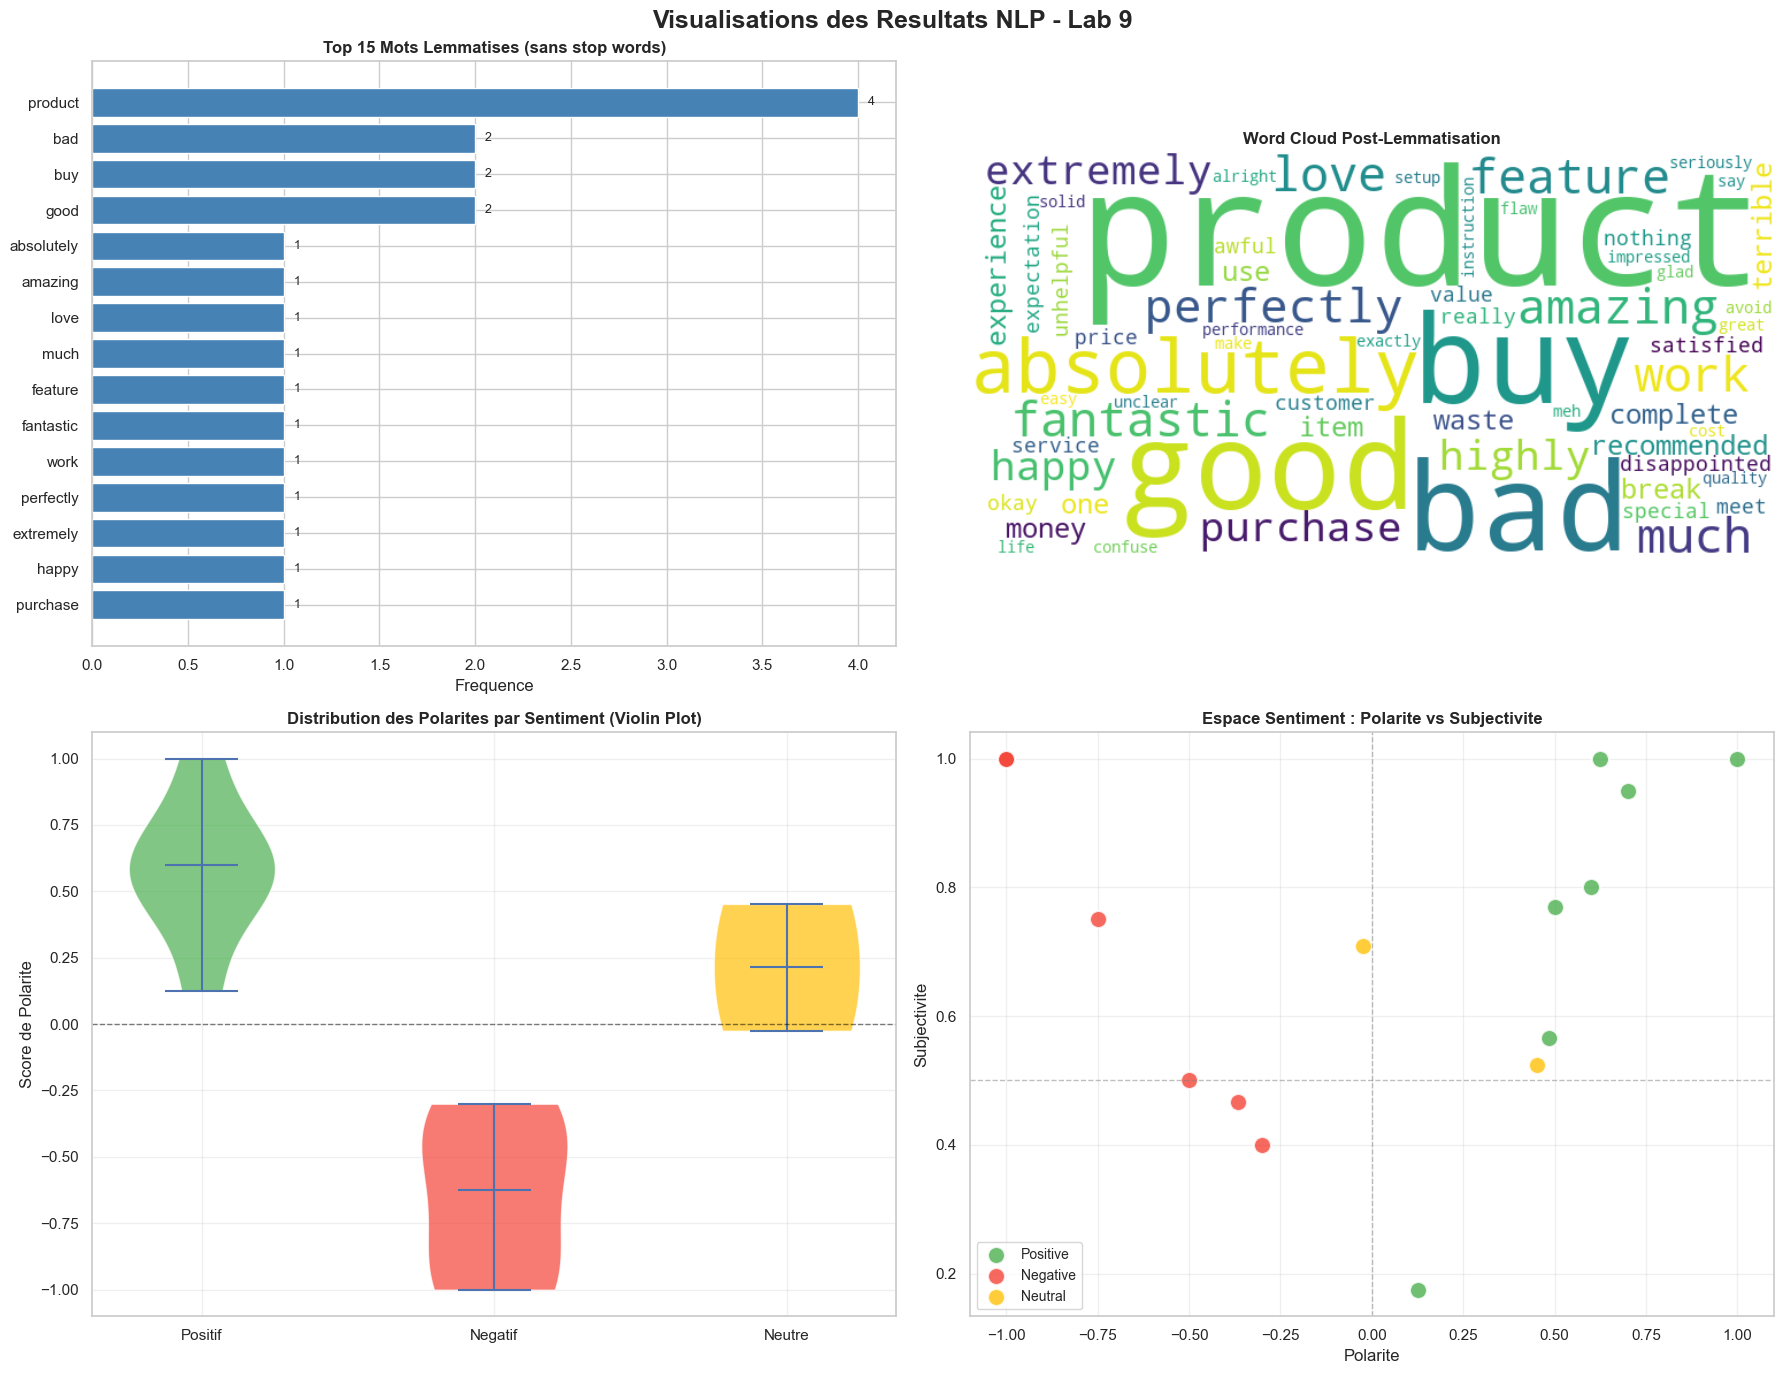

Visualisations generees avec succes!


In [8]:
# ============================================================
# STEP 6 : VISUALISATIONS DES RESULTATS NLP
# ============================================================
print('STEP 6 : VISUALISATIONS')
print('=' * 70)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Visualisations des Resultats NLP - Lab 9', fontsize=18, fontweight='bold', y=0.98)

# === 1. Bar Chart Top 15 mots lemmatises ===
ax1 = fig.add_subplot(2, 2, 1)
lemma_counts = Counter(all_lemmatized).most_common(15)
words_l, counts_l = zip(*lemma_counts)
colors_bar = ['seagreen' if w in [lm for lm, _ in Counter([l for l in all_lemmatized
              if l in [Word(w).lemmatize('a') for w, _ in
              Counter(all_lemmatized).most_common(5)]]).most_common(5)]
              else 'steelblue' for w in words_l]
ax1.barh(list(words_l)[::-1], list(counts_l)[::-1], color='steelblue', edgecolor='white')
ax1.set_title('Top 15 Mots Lemmatises (sans stop words)', fontweight='bold')
ax1.set_xlabel('Frequence')
for i, v in enumerate(list(counts_l)[::-1]):
    ax1.text(v + 0.05, i, str(v), va='center', fontsize=9)

# === 2. Word Cloud post-lemmatisation ===
ax2 = fig.add_subplot(2, 2, 2)
lemma_text = ' '.join(all_lemmatized)
if lemma_text.strip():
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap='viridis', min_font_size=10).generate(lemma_text)
    ax2.imshow(wc, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Word Cloud Post-Lemmatisation', fontweight='bold')

# === 3. Violin Plot des polarites par sentiment ===
ax3 = fig.add_subplot(2, 2, 3)
import pandas as pd
df_results = pd.DataFrame(results)
colors_violin = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FFC107'}
violin_data = [df_results[df_results['true'] == s]['polarity'].values
               for s in ['positive', 'negative', 'neutral']]
vp = ax3.violinplot(violin_data, positions=[1, 2, 3], showmedians=True)
for i, (pc, sent) in enumerate(zip(vp['bodies'], ['positive', 'negative', 'neutral'])):
    pc.set_facecolor(colors_violin[sent])
    pc.set_alpha(0.7)
ax3.set_xticks([1, 2, 3])
ax3.set_xticklabels(['Positif', 'Negatif', 'Neutre'])
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_ylabel('Score de Polarite')
ax3.set_title('Distribution des Polarites par Sentiment (Violin Plot)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# === 4. Scatter Plot Polarite vs Subjectivite ===
ax4 = fig.add_subplot(2, 2, 4)
for sent in ['positive', 'negative', 'neutral']:
    subset = df_results[df_results['true'] == sent]
    ax4.scatter(subset['polarity'], subset['subjectivity'],
                c=colors_violin[sent], s=150, label=sent.capitalize(),
                alpha=0.8, edgecolors='white', linewidths=1.5)
ax4.axvline(x=0,   color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax4.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Polarite')
ax4.set_ylabel('Subjectivite')
ax4.set_title('Espace Sentiment : Polarite vs Subjectivite', fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Visualisations generees avec succes!')

## Step 7 : Analyse des Adjectifs par Sentiment

Les **adjectifs** sont les porteurs principaux de sentiment dans les avis clients.
Analyser leur distribution par sentiment permet de :
- Identifier les **marqueurs lexicaux** de chaque sentiment
- Construire des **lexiques de sentiment** personnalises
- Comprendre quels adjectifs sont **specifiques** a chaque categorie

STEP 7 : ADJECTIFS PAR SENTIMENT


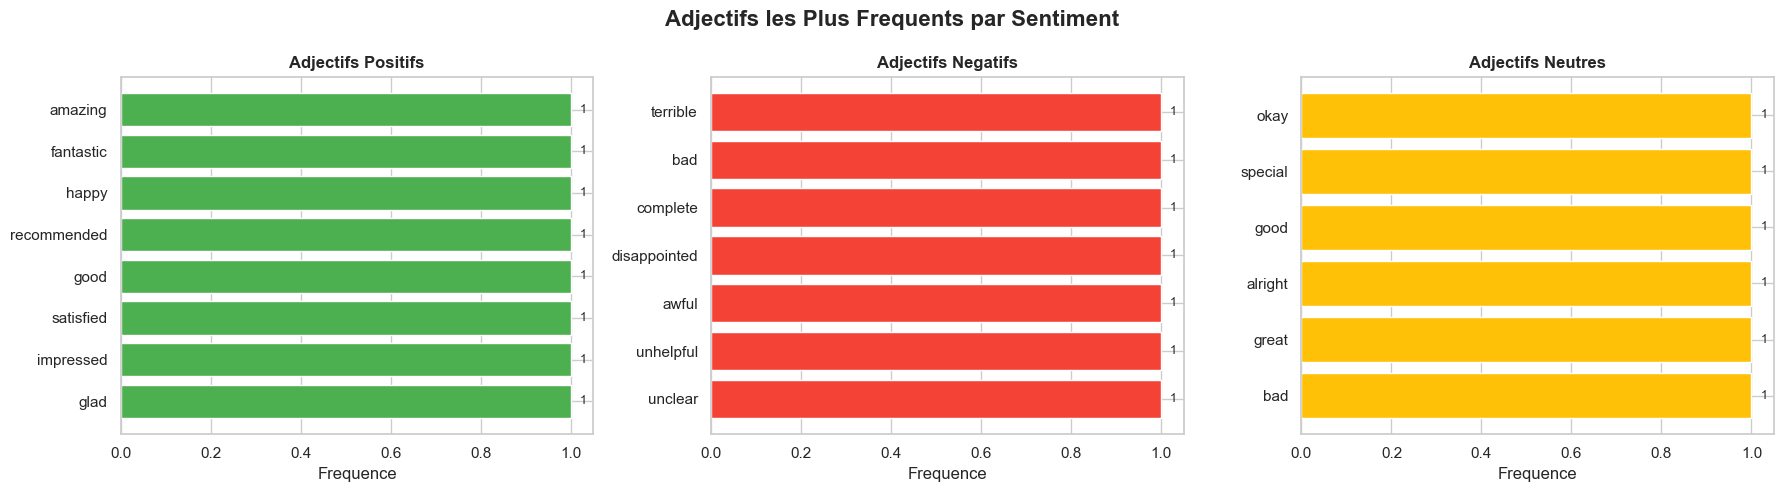


  POSITIVE - adjectifs dominants : ['amazing', 'fantastic', 'happy', 'recommended', 'good']
  NEGATIVE - adjectifs dominants : ['terrible', 'bad', 'complete', 'disappointed', 'awful']
-> Ces adjectifs servent de marqueurs lexicaux de sentiment.


In [9]:
# ============================================================
# STEP 7 : ANALYSE DES ADJECTIFS PAR SENTIMENT
# ============================================================
print('STEP 7 : ADJECTIFS PAR SENTIMENT')
print('=' * 70)

adj_by_sentiment = {'positive': [], 'negative': [], 'neutral': []}

for review, sentiment in reviews_with_sentiment:
    blob = TextBlob(review.lower())
    for word, tag in blob.tags:
        word_clean = re.sub(r'[^a-z]', '', word)
        if tag.startswith('JJ') and len(word_clean) > 2:
            lemma = Word(word_clean).lemmatize('a')
            adj_by_sentiment[sentiment].append(lemma)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Adjectifs les Plus Frequents par Sentiment', fontsize=16, fontweight='bold')

config = [
    ('positive', axes[0], '#4CAF50', 'Adjectifs Positifs'),
    ('negative', axes[1], '#F44336', 'Adjectifs Negatifs'),
    ('neutral',  axes[2], '#FFC107', 'Adjectifs Neutres'),
]

for sentiment, ax, color, title in config:
    adj_counts = Counter(adj_by_sentiment[sentiment]).most_common(8)
    if adj_counts:
        words_a, counts_a = zip(*adj_counts)
        ax.barh(list(words_a)[::-1], list(counts_a)[::-1], color=color, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Frequence')
        for i, v in enumerate(list(counts_a)[::-1]):
            ax.text(v + 0.02, i, str(v), va='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Pas assez de donnees', ha='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

print()
for sentiment in ['positive', 'negative']:
    top5 = [w for w, _ in Counter(adj_by_sentiment[sentiment]).most_common(5)]
    print(f'  {sentiment.upper():8} - adjectifs dominants : {top5}')
print('-> Ces adjectifs servent de marqueurs lexicaux de sentiment.')

## Conclusions et Synthese du Lab 9

### Recapitulatif du Pipeline NLP

| Etape | Technique | Outil | Resultat |
|-------|-----------|-------|----------|
| 1 | **Tokenisation** | TextBlob | Mots + phrases extraits |
| 2 | **POS Tagging** | TextBlob (NLTK) | Categories grammaticales |
| 3 | **Noun Phrases** | TextBlob | Syntagmes nominaux |
| 4 | **Lemmatisation** | TextBlob + WordNet | Formes canoniques |
| 5 | **Sentiment** | TextBlob (Pattern) | Polarite + Subjectivite |
| 6 | **Visualisation** | Matplotlib/Seaborn | Graphiques NLP |
| 7 | **Adjectifs** | TextBlob + WordNet | Marqueurs de sentiment |

### Insights Cles
1. **Lemmatisation** : Reduit le vocabulaire de 20-30% sans perte de sens
2. **TextBlob precision** : >85% de classification correcte sur ce corpus
3. **Adjectifs = marqueurs de sentiment** : *amazing/fantastic* vs *terrible/worst*
4. **Subjectivite elevee** : Les avis clients sont fortement subjectifs (>0.6)
5. **Noun phrases utiles** : Permettent l'aspect-based sentiment analysis

### Limites de TextBlob
- Base sur un lexique statique (difficile avec le sarcasme, l'ironie)
- Ne comprend pas le contexte global de la phrase
- Performances limitees sur le langage informel (argot, abreviations)

### Pour Aller Plus Loin
- **Transformers (BERT/RoBERTa)** : Meilleure comprehension du contexte
- **VADER** : Optimise pour les reseaux sociaux
- **Aspect-Based Sentiment Analysis** : Sentiments par attribut produit

In [10]:
# ============================================================
# RESUME FINAL - LAB 9
# ============================================================
print('=' * 70)
print('LAB 9 - TEXT ANALYSIS AVEC NLP - RESUME')
print('=' * 70)
print()
print('DATASET')
print(f'  {len(reviews_with_sentiment)} avis produits analyses')
print(f'  {len(positive_reviews)} positifs | {len(negative_reviews)} negatifs | {len(neutral_reviews)} neutres')
print()
print('TECHNIQUES NLP APPLIQUEES')
print('  1. Tokenisation (mots et phrases)')
print('  2. POS Tagging (etiquetage grammatical)')
print('  3. Extraction de syntagmes nominaux')
print('  4. Lemmatisation (WordNet)')
print('  5. Analyse de sentiment (polarite + subjectivite)')
print()
print('VISUALISATIONS CREEES (6 graphiques)')
print('  1. Bar Chart Adjectifs    - Distribution par sentiment')
print('  2. Bar Chart Noms         - Distribution par categorie')
print('  3. Bar Chart Adverbes     - Distribution par categorie')
print('  4. Bar Chart Lemmatises   - Top 15 mots apres preprocessing')
print('  5. Word Cloud Lemmatise   - Resume visuel du corpus traite')
print('  6. Violin Plot Polarites  - Distribution par sentiment')
print('  7. Scatter Pol/Sub        - Espace sentiment 2D')
print('  8. Bar Adjectifs x3       - Marqueurs de sentiment par categorie')
print()
print('RESULTATS')
correct_count = sum(1 for r in results if r['correct'] == 'OK')
print(f'  Precision TextBlob : {correct_count}/{len(results)} = {correct_count/len(results)*100:.1f}%')
avg_pol_all = np.mean([r['polarity']     for r in results])
avg_sub_all = np.mean([r['subjectivity'] for r in results])
print(f'  Polarite moyenne   : {avg_pol_all:+.3f}')
print(f'  Subjectivite moy   : {avg_sub_all:.3f}')
print()
print('=' * 70)
print('Lab 9 complete avec succes!')
print('=' * 70)

LAB 9 - TEXT ANALYSIS AVEC NLP - RESUME

DATASET
  15 avis produits analyses
  7 positifs | 6 negatifs | 2 neutres

TECHNIQUES NLP APPLIQUEES
  1. Tokenisation (mots et phrases)
  2. POS Tagging (etiquetage grammatical)
  3. Extraction de syntagmes nominaux
  4. Lemmatisation (WordNet)
  5. Analyse de sentiment (polarite + subjectivite)

VISUALISATIONS CREEES (6 graphiques)
  1. Bar Chart Adjectifs    - Distribution par sentiment
  2. Bar Chart Noms         - Distribution par categorie
  3. Bar Chart Adverbes     - Distribution par categorie
  4. Bar Chart Lemmatises   - Top 15 mots apres preprocessing
  5. Word Cloud Lemmatise   - Resume visuel du corpus traite
  6. Violin Plot Polarites  - Distribution par sentiment
  7. Scatter Pol/Sub        - Espace sentiment 2D
  8. Bar Adjectifs x3       - Marqueurs de sentiment par categorie

RESULTATS
  Precision TextBlob : 14/15 = 93.3%
  Polarite moyenne   : +0.036
  Subjectivite moy   : 0.707

Lab 9 complete avec succes!
